In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import icechunk
from icechunk.xarray import to_icechunk
from dask.distributed import Client
from evaltools.source import get_source_collection, open_and_sort, open_datasets

In [3]:
client = Client(dashboard_address="localhost:8787", threads_per_worker=1)

In [4]:
catalog = get_source_collection(variable_id=["tas", "pr"], frequency="mon", add_fx=["sftlf", "orog"])
dsets = open_and_sort(catalog, merge_fx=True)
ds = dsets['CORDEX-CMIP6.EUR-12.GERICS.ERA5.evaluation.r1i1p1f1.REMO2020-2-2-iMOVE.v1-r1.mon.v20250515']

Opening catalog from https://raw.githubusercontent.com/euro-cordex/joint-evaluation/refs/heads/main/CORDEX-CMIP6.json
Found 27 datasets for variables ['tas', 'pr']: ['RACMO22E', 'RCA4', 'CCLM4-8-17', 'HadREM3-GA7-05', 'REMO2009', 'REMO2015', 'ALADIN53', 'ALADIN63', 'RegCM4-2', 'COSMO-crCLIM-v1-1', 'ALARO-0', 'RACMO23E', 'COSMO-CLM-6-0-clm3', 'ICON-CLM-202407-1-1', 'CCLM6-0-1-URB', 'v1-r1', 'HCLIM43-ALADIN', 'ROAM-NBS', 'REMO2020-2-2', 'REMO2020-2-2-iMOVE-LUC', 'REMO2020-2-2-MR2', 'REMO2020-2-2-iMOVE', 'WRF451Q', 'CCLM6-0-1-URB-ESG', 'CNRM-ALADIN64E1', 'RegCM5-0', 'ALARO1-SFX']

--> The keys in the returned dictionary of datasets are constructed as follows:
	'project_id.domain_id.institution_id.driving_source_id.driving_experiment_id.driving_variant_label.source_id.version_realization.frequency.version'


2025-10-05 16:48:36,539 - distributed.worker - ERROR - Compute Failed
Key:       _delayed_open_ds-11251a03-6aa9-4524-9ee0-0440161ca5b6
State:     executing
Task:  <Task '_delayed_open_ds-11251a03-6aa9-4524-9ee0-0440161ca5b6' _delayed_open_ds(..., ...)>
Exception: 'ValueError(\'Failed to decode variable \\\'time\\\': unable to decode time units \\\'months since 1980-1-1 00:00:00\\\' with "calendar \\\'standard\\\'". Try opening your dataset with decode_times=False or installing cftime if it is not installed.\')'
Traceback: '  File "/mnt/CORDEX_CMIP6_tmp/user_tmp/lbuntemeyer/conda_envs/cordex-etl/lib/python3.13/site-packages/intake_esm/source.py", line 60, in _delayed_open_ds\n    return _open_dataset(*args, **kwargs)\n  File "/mnt/CORDEX_CMIP6_tmp/user_tmp/lbuntemeyer/conda_envs/cordex-etl/lib/python3.13/site-packages/intake_esm/source.py", line 99, in _open_dataset\n    ds = xr.open_dataset(url, **xarray_open_kwargs)\n  File "/mnt/CORDEX_CMIP6_tmp/user_tmp/lbuntemeyer/conda_envs/cordex

decoding dataset CORDEX-CMIP6.EUR-12.HCLIMcom-SMHI.CNRM-ESM2-1.ssp126.r1i1p1f2.HCLIM43-ALADIN.v1-r1.fx.v20241205
Found 120 datasets
decoding dataset CORDEX-CMIP6.EUR-12.CLMcom-KIT.MIROC6.historical.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.fx.v20240920
Warning for CORDEX-CMIP6.EUR-12.CLMcom-KIT.MIROC6.historical.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.fx.v20240920: Variable(s) referenced in cell_measures not in variables: ['areacella']
Warning for CORDEX-CMIP6.EUR-12.CLMcom-KIT.MIROC6.historical.r1i1p1f1.ICON-CLM-202407-1-1.v1-r1.fx.v20240920: Variable(s) referenced in cell_measures not in variables: ['areacella']
Found 120 datasets
decoding dataset CORDEX.EUR-11.CNRM.ERAINT.evaluation.r1i1p1.ALADIN53.v1.fx.v20150127
Found 120 datasets
decoding dataset CORDEX.EUR-11.RMIB-UGent.ERAINT.evaluation.r1i1p1.ALARO-0.v1.fx.v20170523
Found 120 datasets
decoding dataset CORDEX.EUR-11.MPI-CSC.ERAINT.evaluation.r1i1p1.REMO2009.v1.mon.v20160525
Found 120 datasets
decoding dataset CORDEX-CMIP6.EUR-12.HCLIMcom-D

## Create icechunk repository

In [5]:
storage_config = icechunk.s3_storage(
    bucket="euro-cordex",
    prefix="cmip6-icechunk",
    region='eu-central-1',
)
repo = icechunk.Repository.create(storage_config)
session = repo.writable_session("main")
to_icechunk(ds, session)

first_snapshot = session.commit("add REMO2020-2-2-iMOVE.v1-r1.mon.v20250515")
print(first_snapshot)

xr.set_options(display_style="text")
print(xr.open_zarr(session.store, consolidated=False))

AQ1GR141B3EMV9KES0RG
<xarray.Dataset> Size: 703MB
Dimensions:                     (rlat: 412, rlon: 424, time: 492, vertices: 4,
                                 bnds: 2)
Coordinates:
    height                      float64 8B ...
  * rlon                        (rlon) float64 3kB -28.38 -28.27 ... 18.05 18.16
    lat                         (rlat, rlon) float64 1MB dask.array<chunksize=(412, 424), meta=np.ndarray>
    lon                         (rlat, rlon) float64 1MB dask.array<chunksize=(412, 424), meta=np.ndarray>
  * rlat                        (rlat) float64 3kB -23.38 -23.27 ... 21.73 21.84
  * time                        (time) datetime64[ns] 4kB 1980-01-16T12:00:00...
Dimensions without coordinates: vertices, bnds
Data variables:
    orog                        (rlat, rlon) float32 699kB dask.array<chunksize=(412, 424), meta=np.ndarray>
    pr                          (time, rlat, rlon) float32 344MB dask.array<chunksize=(1, 412, 424), meta=np.ndarray>
    rotated_latitude_l

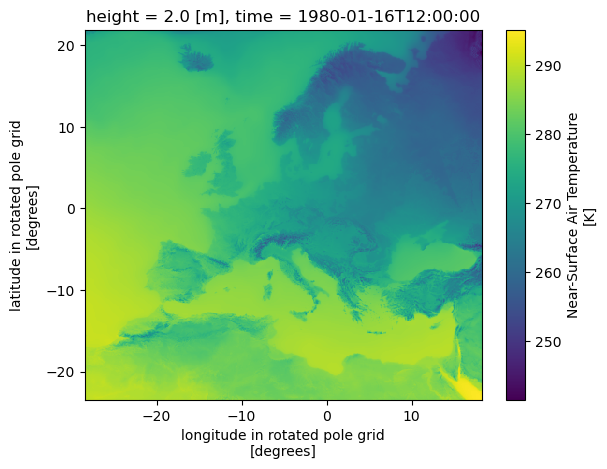

In [6]:
xr.open_zarr(session.store, consolidated=False).isel(time=0).tas.plot()